# Assignment 6.1

Name:  
Date:

For this assignment, you will refer to the textbook to solve the practice exercises. **Use Python to answer any coding problems (not R, even if indicated in your textbook).** Use Jupyter Notebook, Google Colab, or a similar software program to complete your assignment. Submit your answers as a **PDF or HTML** file. As a best practice, always label your axes and provide titles for any graphs generated on this assignment. Round all quantitative answers to 2 decimal places.

## Problem 6.1.

For the Scottish hill `Races` data, a linear model can predict men’s record times from women’s record times.  
http://stat4ds.rwth-aachen.de/data/ScotsRaces.dat


(a)  Show the scatterplot and report the prediction equation. Predict the men’s record time for the Highland Fling, for which timeW = 490.05 minutes.


`Your answer goes here`

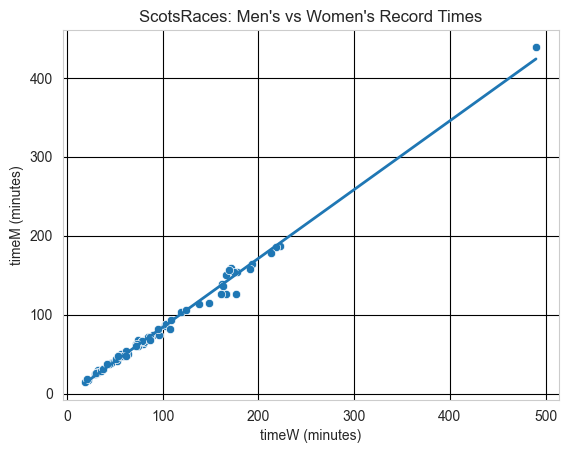


The predicted equations is
y_hat = b0 + b1 * x0 = 423.945
w/ b0 = -2.83,  b1 = 0.87 and x0=490.05
      


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from textwrap import dedent

def read_file(path):
    """
    Reads file
    ----------------------------
    INPUT:
        path: (str)

    OUTPUT:
        (pd.DataFrame)
    """
    try:
        if path.endswith(".csv"):
            return pd.read_csv(path)

        elif path.endswith(".dat"):
            return pd.read_csv(path, sep="\s+")

        else:
            raise ValueError("File must end with .csv or .dat")

    except Exception as err:
        print(f"\nOOPS! -> {err}")

        return None

def sample_mean(var):
    """
    Returns the mean of the input variable (sample mean in this case).
    """
    # INput validation
    if not isinstance(var, pd.Series):
        raise("Input not valid\nNot a pandas Series")

    return var.mean()

def sample_stats(x, y):
    """
    Computes the sample means and samples standard deviations.
    ---------------------------------------------
    INPUT:
        x: (pd.Series)
        y: (pd.Series)
    
    OUTPUT:
        (x_bar, y_bar, sxx, sxy, syy): (tuple)
    """
    # Sample means
    x_bar, y_bar = sample_mean(x), sample_mean(y)

    # Sample standard deviations
    sxx = np.sum((x - x_bar)**2)
    sxy = np.sum((x - x_bar) * (y - y_bar))
    syy = np.sum((y - y_bar)**2)

    return x_bar, y_bar, sxx, sxy, syy

def linear_fit(x_bar, y_bar, sxx, sxy):
    """
    Fits the model using least squares.
    
    WHY THE MATH, MATHS:
    -------------------
    b1_hat = sxy / sxx
        = (sum((xi - x_bar) * (yi - y_bar)) / sum((xi - x_bar)^2)
    b0_hat = y_bar - b1_hat * x_bar
    --------------------------------------------------------
    INPUT:
        x_bar: (np.float)
        y_bar: (np.float)
        sxx: (np.float)
        sxy: (np.float)

    OUTPUT:
        (b0_hat, b1_hat): (tuple)
    """
    # Estimate parameters
    b1_hat = sxy / sxx
    b0_hat = y_bar - b1_hat * x_bar

    return b0_hat, b1_hat

def correlation(Sxx, Sxy, Syy):
    """
    Computes sample correlation (r).

    r = Sxy / sqrt(Sxx * Syy)
    ----------------------------------
    INPUT:
        Sxx: (np.float)
        Sxy: (np.float)
        syy: (np.float)
        
    OUTPUT:
        r: (np.float) Correlation
    """
    return Sxy / np.sqrt(Sxx * Syy)

def line_thru_origin(x, y):
    """
    Fits the no-intercept line through the origin.
    yi = b_1 * xi

    With b_0 = 0, we minimize LEAST SQUARES: sum(yi - b_1 * xi)**2,
    by taking derivative: -2*sum(xi*yi) + 2*b_1*sum(xi**2)
    -------------------------------------------------
    INPUT:
        x: (pd.Series) Expanatory variables
        y: (pd.Series) Target

    OUTPUT:
        b_hat: (np.float)
    """
    b_hat = np.sum(x * y) / sum(x**2)

    return b_hat

# =========== Main ==============
# Load data
df = read_file("./ScotsRaces.dat")

# Explanatory/Target variables
X = df["timeW"] # Women's time in minutes
y = df["timeM"] # Men's time in minutes

# Sample means and sample standard deviations
x_bar, y_bar, sxx, sxy, syy  = sample_stats(X, y)

# a) ======= Fit model and prediction equation ========
# Estimating parameters
b0, b1 = linear_fit(x_bar, y_bar, sxx, sxy)

# Set white background with black grid
sns.set_style("whitegrid", {'grid.color': 'black'})
sns.scatterplot(df, x="timeW", y="timeM")

# Fitted line: y_hat = b0 + b1 * x (over 200 evenly spaced values)
x_line = np.linspace(X.min(), X.max(), 200)
# Line to go on scatterplot
y_line = b0 + b1 * x_line

# Plotting
plt.plot(x_line, y_line, linewidth=2)

plt.title("ScotsRaces: Men's vs Women's Record Times")
plt.xlabel("timeW (minutes)")
plt.ylabel("timeM (minutes)")
plt.show()

# Predict men's time for HighlandFling while timeW=490.05
x0 = 490.05

# Equation
y_hat = b0 + b1 * x0

# Output
print(f"""
The predicted equations is
y_hat = b0 + b1 * x0 = {y_hat:.3f}
w/ b0 = {b0:.2f},  b1 = {b1:.2f} and x0={x0}
      """)


(b) Find and interpret the correlation.

`Your answer goes here`

(c) We could impose the natural constraint that when timeW = 0, then timeM = 0. Fit the model $E(Y_i)=\beta x_i.$ Interpret the estimated slope.

`Your answer goes here`

## Problem 6.2.

For advanced industrialized nations, the Firearms data file at the text website shows annual homicide rates (per million population) and the number of firearms (per 100 people), with data taken from Wikipedia and [smallarmssurvey.org](smallarmssurvey.org).

(a) Construct a scatterplot and highlight any observations that fall apart from the general trend.

`Your answer goes here`

(b) Find the correlation with and without the outlying observation. Why is it so different in the two cases?

`Your answer goes here`

(c) Fit the linear regression model with and without the outlying observation, and note how influential an outlier can be on the fit.

`Your answer goes here`

## Problem 6.5.

For the `Covid19` data file at the text website:  
http://stat4ds.rwth-aachen.de/data/Covid19.dat 

(a) Construct the two scatterplots shown in Figure 6.3.

`Your answer goes here`

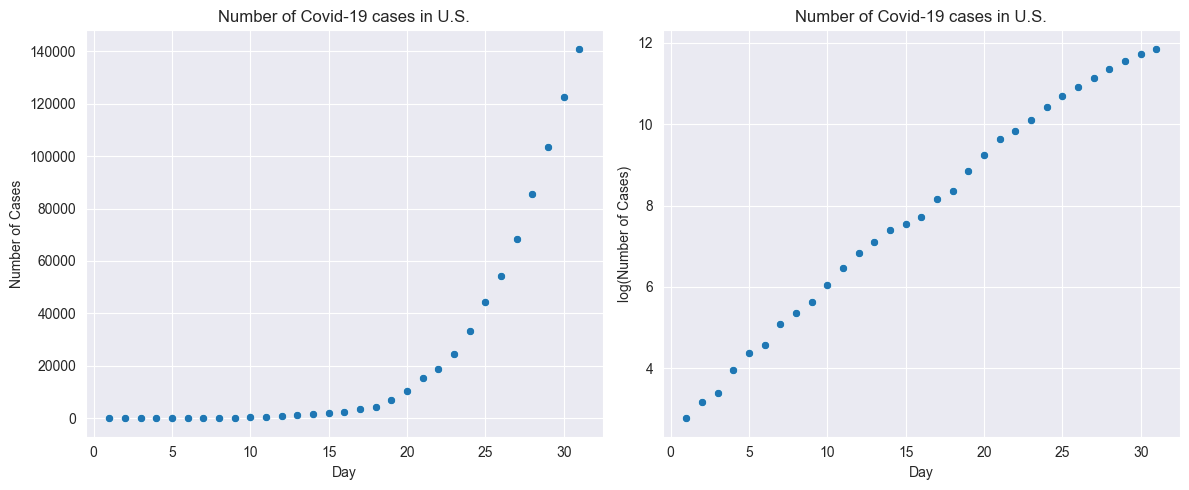

In [2]:
df = read_file("./covid19.dat")

# Explanatory/Target
X = df["day"]
y = df["cases"]

# Log transformation
log_y = np.log(y)

# a) ==== Scatter plots ====
# Add gridlines cuz i want to  ( ͡° ͜ʖ ͡°)
sns.set_style("darkgrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1
# Using pre-existing axes for plot
sns.scatterplot(data=df, x="day", y="cases", ax=ax1)
ax1.set(title="Number of Covid-19 cases in U.S.", xlabel="Day", ylabel="Number of Cases")

# Plot 2
sns.scatterplot(data=df, x="day", y=log_y, ax=ax2)
ax2.set(title="Number of Covid-19 cases in U.S.", xlabel="Day", ylabel="log(Number of Cases)")

plt.tight_layout()
plt.show()


(b) Find and interpret the correlation between time and (i) cases, (ii) log(cases).

`Your answer goes here`

(c)  Fit the linear model for the log-transformed counts and report the prediction equation.$^{29}.$ Explain why the predicted count at day $x+1$ equals the predicted count at day $x$ multiplied by $\text{exp}(\hat\beta_1)=1.36.$

`Your answer goes here`

## Problem 6.8.

Refer to the example in Section 6.2.5 of the crime rate in Florida counties.

(a) Explain what it means when we say these data exhibit *Simpson’s paradox*. What could cause this change in the direction of the association between crime rate and education
when we adjust for urbanization?

`Your answer goes here`

(b) Using the Florida data file, construct the scatterplot between *x* = education (HS) and *y* = income (Income), for which the correlation is 0.79. If we had data at the individual
level as well as aggregated for a county, sketch a scatterplot to show that at that level the correlation could be much weaker. So, predictions about individuals based on the
behavior of aggregate groups, known as the *ecological fallacy*, can be quite misleading.

`Your answer goes here`

(c) Refer to (b), in which *x* falls between 54.5 and 84.9. Is it sensible to use the least squares line to predict a county’s median income if *x* = 0? Sketch a hypothetical true relationship between *x* and *E(Y)* to show the danger of *extrapolation*, using a fitted line to predict *E(Y)* far from the observed *x* values.

`Your answer goes here`

## Problem 6.10.

The `Students` data file shows responses on variables summarized in Exercise 1.2.

(a) Fit the linear model using *hsgpa* = high school GPA, *tv* = weekly hours watching TV, and *sport* = weekly hours participating in sports as predictors of *cogpa* = college GPA. Report the prediction equation. What do the *P*-values suggest?

`Your answer goes here`

(b)  Summarize the estimated effect of *hsgpa.*

`Your answer goes here`

(c) Report and interpret $R^2$, adjusted $R^2$, and the multiple correlation.

`Your answer goes here`

## Problem 6.12.

For the `UN` data file at the book’s website (see Exercise 1.24), construct a multiple regression model predicting Internet using all the other variables. Use the concept of multicollinearity to explain why adjusted $R^2$ is not dramatically greater than when GDP is the sole predictor. Compare the estimated GDP effect in the bivariate model and the multiple regression model and explain why it is so much weaker in the multiple regression model.

`Your answer goes here`

## Problem 7.1.

For the `Houses` data file described in Section 7.1.3, consider $Y$ = selling price, $x_1$ = tax bill (in dollars), and $x_2$ = whether the house is new.

(a) Form the scatterplot of $y$ and $x_1$. Does the normal GLM structure of constant variability in $y$ seem approproate? If not, how does it seem to be violated?

`Your answer goes here`

(b) Using the identity link function, fit the (i) normal GLM, (ii) gamma GLM. For each model, interpret the effect of $x_2$.

`Your answer goes here`

(c) For each model, describe how the estimated variability in selling prices varies as the mean selling price varies from 100 thousand to 500 thousand dollars.

`Your answer goes here`

(d) Which model is preferred according to AIC?

`Your answer goes here`

## Problem 7.5.

A study of sheep mentioned in Exercise 1.27 analyzed whether the sheep survived for a year from the original observation time (1 = yes, 0 = no) as a function of their weight (*kg*) at the original observation.

(a) Does the survival of the sheep seem to depend on their weight? If so, how does the weight of a sheep affect its probability of survival? Answer by fitting a generalized linear model for the survival probability.

`Your answer goes here`

(b)  For what weight values do the sheep have more than a 50% chance of survival?

`Your answer goes here`

## Problem 7.9.

The `SoreThroat` data file at the book’s website contains data from from a study$^{23}$ about *Y* = whether a patient having surgery had a sore throat on waking (1 = yes, 0 = no) as a function of *D* = duration of the surgery (in minutes) and *T* = type of device used to secure the airway (1 = tracheal tube, 0 = laryngeal mask airway).

(a) Fit a GLM using both explanatory variables as main effects. Interpret effects.

`Your answer goes here`

(b) Fit a GLM permitting interaction between the explanatory variables. Interpret the effect of *D* at each category of *T*.

`Your answer goes here`

## 7.10 Predicting Diabetes Using Logistic Regression

In this exercise, you will build a simple AI classification model using logistic regression to predict whether a patient has diabetes. You will use the Diabetes dataset available directly from sklearn.datasets.

### Task

Load the diabetes dataset, explore the features, and build a logistic regression model that predicts the presence of diabetes.
Then, discuss whether logistic regression is appropriate for this AI task based on what we have covered in class.

### Your Steps

1. Load the diabetes dataset from sklearn.

2. Split the data into training and test sets.

3. Fit a logistic regression model. *Hint: Scale the features if necessary.*

4. Evaluate accuracy, f1 score, precision, recall, and roc auc on the test set.

5. Write a short reflection: does logistic regression seem like a reasonable AI model for this problem? Why or why not?

### Starter Code

1. Load the diabetes dataset from sklearn

In [1]:
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import pandas as pd

# 1. Load the dataset
data = load_diabetes()

2. Split the data into training and test sets.

3. Fit a logistic regression model. *Hint: Scale the features if necessary.*

4. Evaluate accuracy, f1 score, precision, recall, and roc auc on the test set.

5. Write a short reflectmion: does logistic regression seem like a reasonable AI model for this problem? Why or why not?

&nbsp;
&nbsp;
&nbsp;
&nbsp;
&nbsp;
&nbsp;
&nbsp;
&nbsp;


----------------
$^{23}$ Described in “Binary Data” by D. Collett, *Encyclopedia of Biostatistics*, 2nd ed. (Wiley, 2005), pp. 439–446.

$^{29}$ Some lack of fit the last few days reflects the impact of increasing “social distancing.”